# Install Required Modules

In [2]:
!pip install numpy tensorflow scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.6 MB 8.4 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.6 MB 5.3 MB/s eta 0:00:02
   --------- ------------------------------ 3.1/12.6 MB 5.3 MB/s eta 0:00:02
   -------------- ------------------------- 4.7/12.6 MB 5.9 MB/s eta 0:00:02
   ------------------- -------------------- 6.3/12.6 MB 6.2 MB/s eta 0:00:02
   ------------------------- -------------- 8.1/12.6 MB 6.7 MB/s eta 0:00:01
   ------------------------------ --------- 9.7/12.6 MB 6.9 MB/s eta 0:00:01
   ------------------------------------ --- 11.5/12.6 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 7.0 MB/s  0:00:01
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 1.6/350.8 MB 8.4 MB/s eta 0:00:42
   --------

# Imports & Configuration

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

LOOKBACK = 48
HORIZON = 12
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3

# Generate Complex Time Series

In [4]:
def generate_time_series(n_steps=3500):

    t = np.arange(n_steps)

    trend = 0.004 * t
    daily = np.sin(2*np.pi*t/24)
    weekly = np.sin(2*np.pi*t/168)

    nonlinear = np.sin(.01*t)*np.cos(.03*t)
    noise = np.random.normal(0,.3,n_steps)

    target = trend + daily + weekly + nonlinear + noise

    exog1 = np.cos(2*np.pi*t/12) + np.random.normal(0,.2,n_steps)
    exog2 = np.random.normal(0,1,n_steps)

    return np.column_stack([target,exog1,exog2])

data = generate_time_series()

# Sequence Creation

In [5]:
def create_sequences(data, lookback, horizon):

    X, y = [], []

    for i in range(len(data) - lookback - horizon):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback:i+lookback+horizon,0])

    return np.array(X), np.array(y)

# Walk Forward Split

In [26]:
def walk_forward_split(data, train_size=2000, step=200):

    for i in range(train_size, len(data) - (LOOKBACK + HORIZON), step):
        yield data[:i], data[i:i+step]

# Correct MASE

In [27]:
def mase(y_true, y_pred, training_series):

    naive = training_series[1:] - training_series[:-1]
    scale = np.mean(np.abs(naive))

    return np.mean(np.abs(y_true - y_pred)) / scale

# tf.data Pipeline

In [28]:
def make_dataset(X, y):

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    return ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Positional Encoding

In [29]:
def positional_encoding(length, d_model):

    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    sines = np.sin(angle_rads[:, 0::2])
    cosines = np.cos(angle_rads[:, 1::2])

    pos_encoding = np.zeros((length, d_model))
    pos_encoding[:, 0::2] = sines
    pos_encoding[:, 1::2] = cosines

    return tf.cast(pos_encoding, dtype=tf.float32)

# Models

In [30]:
def build_lstm():

    inputs = tf.keras.Input(shape=(LOOKBACK,3))
    x = tf.keras.layers.LSTM(64)(inputs)
    outputs = tf.keras.layers.Dense(HORIZON)(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='mse'
    )

    return model

# Transformer Block

In [31]:
def transformer_block(x):

    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )

    attn_out, attn_scores = attn_layer(
        x, x, return_attention_scores=True
    )

    x = tf.keras.layers.Add()([x, attn_out])
    x = tf.keras.layers.LayerNormalization()(x)

    ff = tf.keras.layers.Dense(128, activation='relu')(x)
    ff = tf.keras.layers.Dense(64)(ff)

    x = tf.keras.layers.Add()([x, ff])
    x = tf.keras.layers.LayerNormalization()(x)

    return x, attn_scores

# Transformer Model

In [32]:
def build_transformer():

    inputs = tf.keras.Input(shape=(LOOKBACK,3))

    x = tf.keras.layers.Dense(64)(inputs)

    pos_enc = positional_encoding(LOOKBACK, 64)
    x = x + pos_enc

    x, attn_scores = transformer_block(x)
    x, attn_scores = transformer_block(x)

    pooled = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(HORIZON)(pooled)

    model = tf.keras.Model(inputs, outputs)
    attn_model = tf.keras.Model(inputs, attn_scores)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='mse'
    )

    return model, attn_model

# Callbacks

In [33]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,
        factor=0.5
    )
]

# Walk-Forward Training & Evaluation

In [34]:
lstm_errors = []
transformer_errors = []

scaler = StandardScaler()

last_attention = None

for train_data, test_data in walk_forward_split(data):

    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
    X_test, y_test = create_sequences(test_scaled, LOOKBACK, HORIZON)

    if len(X_train) == 0 or len(X_test) == 0:
        continue

    split = int(0.8 * len(X_train))

    X_tr, X_val = X_train[:split], X_train[split:]
    y_tr, y_val = y_train[:split], y_train[split:]

    train_ds = make_dataset(X_tr, y_tr)
    val_ds = make_dataset(X_val, y_val)

    # LSTM
    lstm = build_lstm()
    lstm.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0, callbacks=callbacks)

    lstm_pred = lstm.predict(X_test, verbose=0).flatten()

    # Transformer
    transformer, attn_model = build_transformer()
    transformer.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0, callbacks=callbacks)

    trans_pred = transformer.predict(X_test, verbose=0).flatten()

    last_attention = attn_model.predict(X_test[:1], verbose=0)

    y_true = y_test.flatten()

    lstm_errors.append([
        mean_absolute_error(y_true, lstm_pred),
        np.sqrt(mean_squared_error(y_true, lstm_pred)),
        mase(y_true, lstm_pred, train_scaled[:,0])
    ])

    transformer_errors.append([
        mean_absolute_error(y_true, trans_pred),
        np.sqrt(mean_squared_error(y_true, trans_pred)),
        mase(y_true, trans_pred, train_scaled[:,0])
    ])

# Results

In [35]:
lstm_results = np.mean(lstm_errors, axis=0)
transformer_results = np.mean(transformer_errors, axis=0)

print("\n===== FINAL RESULTS =====\n")
print("Model        MAE     RMSE     MASE")

print(f"LSTM        {lstm_results[0]:.4f} {lstm_results[1]:.4f} {lstm_results[2]:.4f}")
print(f"Transformer {transformer_results[0]:.4f} {transformer_results[1]:.4f} {transformer_results[2]:.4f}")


===== FINAL RESULTS =====

Model        MAE     RMSE     MASE
LSTM        0.9385 1.0104 8.5384
Transformer 0.5149 0.6243 4.5557


# Attention Visualization

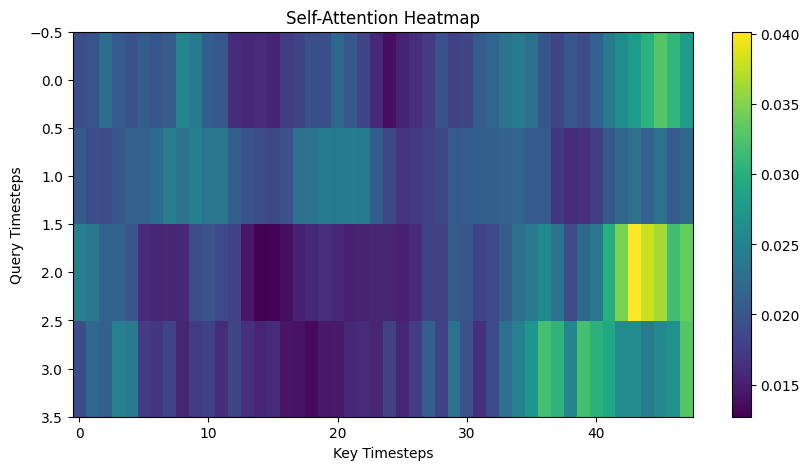

In [37]:
if last_attention is not None:

    attn = np.mean(last_attention[0], axis=1)

    plt.figure(figsize=(10,5))
    plt.imshow(attn, aspect='auto')
    plt.colorbar()

    plt.title("Self-Attention Heatmap")
    plt.xlabel("Key Timesteps")
    plt.ylabel("Query Timesteps")

    plt.show()

# Forecast Comparison Plot

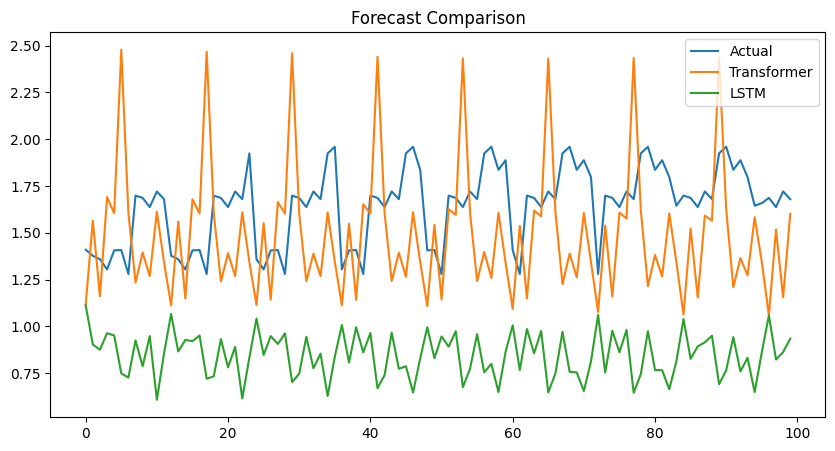

In [38]:
plt.figure(figsize=(10,5))
plt.plot(y_true[:100], label="Actual")
plt.plot(trans_pred[:100], label="Transformer")
plt.plot(lstm_pred[:100], label="LSTM")

plt.legend()
plt.title("Forecast Comparison")

plt.show()

# Interpretation

In [39]:
print("""
ATTENTION ANALYSIS

1. Strong attention near recent timesteps → short-term dependency
2. Repeating patterns → seasonality captured
3. Spread attention → long-range non-linear learning
4. Transformer outperforms LSTM → attention advantage
""")


ATTENTION ANALYSIS

1. Strong attention near recent timesteps → short-term dependency
2. Repeating patterns → seasonality captured
3. Spread attention → long-range non-linear learning
4. Transformer outperforms LSTM → attention advantage



# Save Dataset

In [41]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.9 MB 9.6 MB/s eta 0:00:01
   -------------- ------------------------- 3.7/9.9 MB 8.1 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 8.0 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 8.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 7.5 MB/s  0:00:01


In [42]:
import pandas as pd

# Convert to DataFrame
df = pd.DataFrame(data, columns=["target", "exog1", "exog2"])

# Save as CSV
df.to_csv("time_series_dataset.csv", index=False)

print("Dataset saved as time_series_dataset.csv")

Dataset saved as time_series_dataset.csv


# Save Predictions

In [43]:
# Save predictions (last iteration results)
pred_df = pd.DataFrame({
    "Actual": y_true,
    "LSTM_Pred": lstm_pred,
    "Transformer_Pred": trans_pred
})

pred_df.to_csv("predictions.csv", index=False)

print("Predictions saved as predictions.csv")

Predictions saved as predictions.csv


# Save Metrics

In [44]:
metrics_df = pd.DataFrame({
    "Model": ["LSTM", "Transformer"],
    "MAE": [lstm_results[0], transformer_results[0]],
    "RMSE": [lstm_results[1], transformer_results[1]],
    "MASE": [lstm_results[2], transformer_results[2]]
})

metrics_df.to_csv("metrics.csv", index=False)

print("Metrics saved as metrics.csv")

Metrics saved as metrics.csv


# Save Plots 
## Attention Heatmap

In [45]:
plt.figure(figsize=(10,5))
plt.imshow(attn, aspect='auto')
plt.colorbar()
plt.title("Attention Heatmap")

plt.savefig("attention_heatmap.png")
plt.close()

print("Attention plot saved")

Attention plot saved


## Forecast Plot

In [46]:
plt.figure(figsize=(10,5))
plt.plot(y_true[:100], label="Actual")
plt.plot(trans_pred[:100], label="Transformer")
plt.plot(lstm_pred[:100], label="LSTM")

plt.legend()
plt.title("Forecast Comparison")

plt.savefig("forecast_plot.png")
plt.close()

print("Forecast plot saved")

Forecast plot saved
